In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\PC\\OneDrive\\Desktop\\Học máy\\23000104_NguyenHuuDung_PCA\\iris.csv")

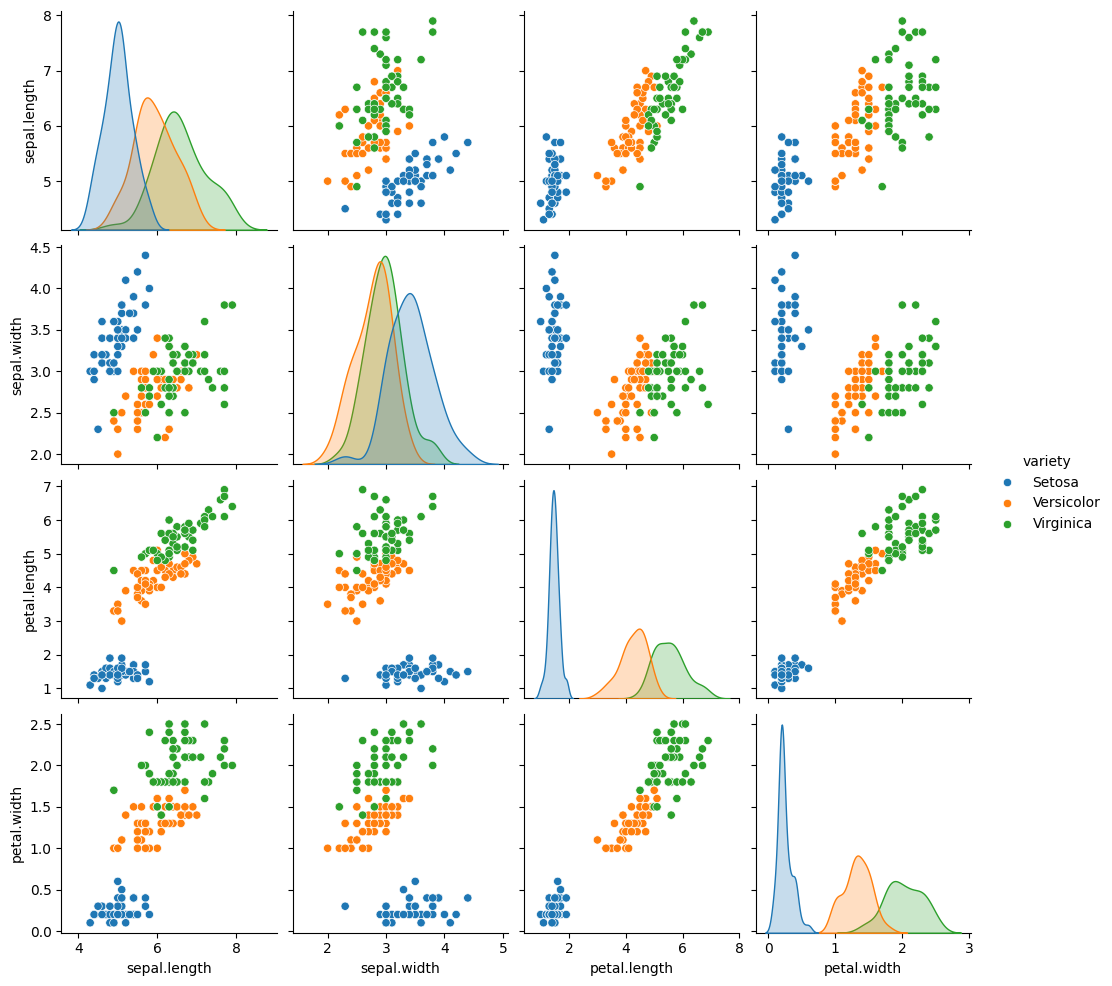

In [6]:
df
df.describe()
sns.pairplot(df, hue = 'variety')

Text(0.5, 1.0, 'corrlation matrix')

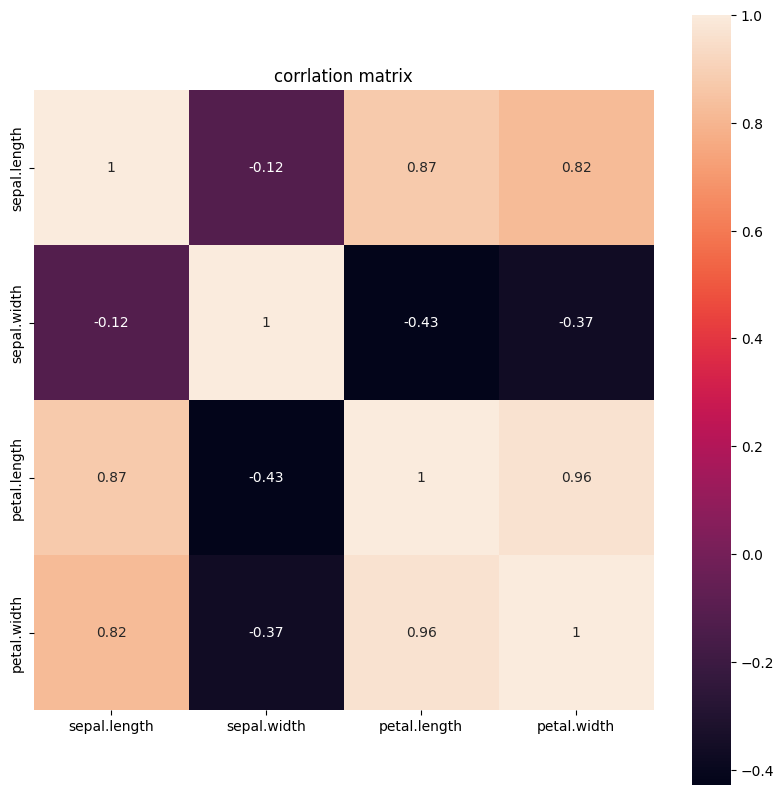

In [12]:
species = df["variety"].tolist()
X = df.drop("variety", axis = 1)
# standardize the data
X = (X - X.mean())/X.std(ddof =0)
X_corrilative = (1/150)*X.T@X
plt.figure(figsize=(10,10))
sns.heatmap(X_corrilative, vmax=1, square=True, annot= True)
plt.title('corrlation matrix')

In [14]:
u,s,v = np.linalg.svd(X_corrilative)
eigens_val, eigens_vector = s,u
eigens_val,eigens_vector


(array([2.91849782, 0.91403047, 0.14675688, 0.02071484]),
 array([[-0.52106591, -0.37741762,  0.71956635,  0.26128628],
        [ 0.26934744, -0.92329566, -0.24438178, -0.12350962],
        [-0.5804131 , -0.02449161, -0.14212637, -0.80144925],
        [-0.56485654, -0.06694199, -0.63427274,  0.52359713]]))

In [15]:
np.linalg.eig(X_corrilative)

EigResult(eigenvalues=array([2.91849782, 0.91403047, 0.14675688, 0.02071484]), eigenvectors=array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
       [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
       [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
       [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

Text(0.5, 0, 'số chiều')

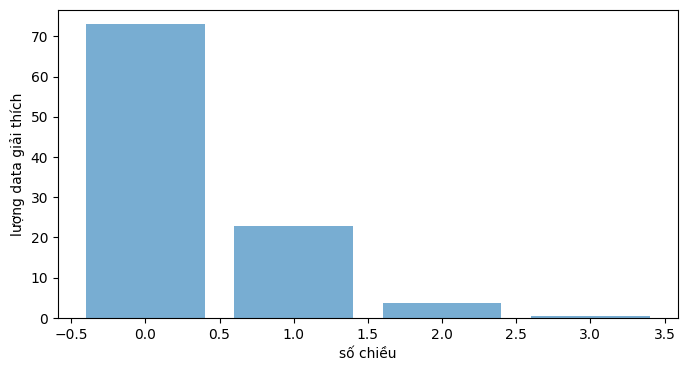

In [16]:
explained_eigns = (eigens_val/np.sum(eigens_val))*100
plt.figure(figsize=(8,4))
plt.bar(range(4),explained_eigns,alpha =0.6)
plt.ylabel("lượng data giải thích")
plt.xlabel("số chiều")

In [17]:
pc1 = X @ eigens_vector[:,0]
pc2 = X @ eigens_vector[:,1]
pc1, pc2

(0      2.264703
 1      2.080961
 2      2.364229
 3      2.299384
 4      2.389842
          ...   
 145   -1.870503
 146   -1.564580
 147   -1.521170
 148   -1.372788
 149   -0.960656
 Length: 150, dtype: float64,
 0     -0.480027
 1      0.674134
 2      0.341908
 3      0.597395
 4     -0.646835
          ...   
 145   -0.386966
 146    0.896687
 147   -0.269069
 148   -1.011254
 149    0.024332
 Length: 150, dtype: float64)

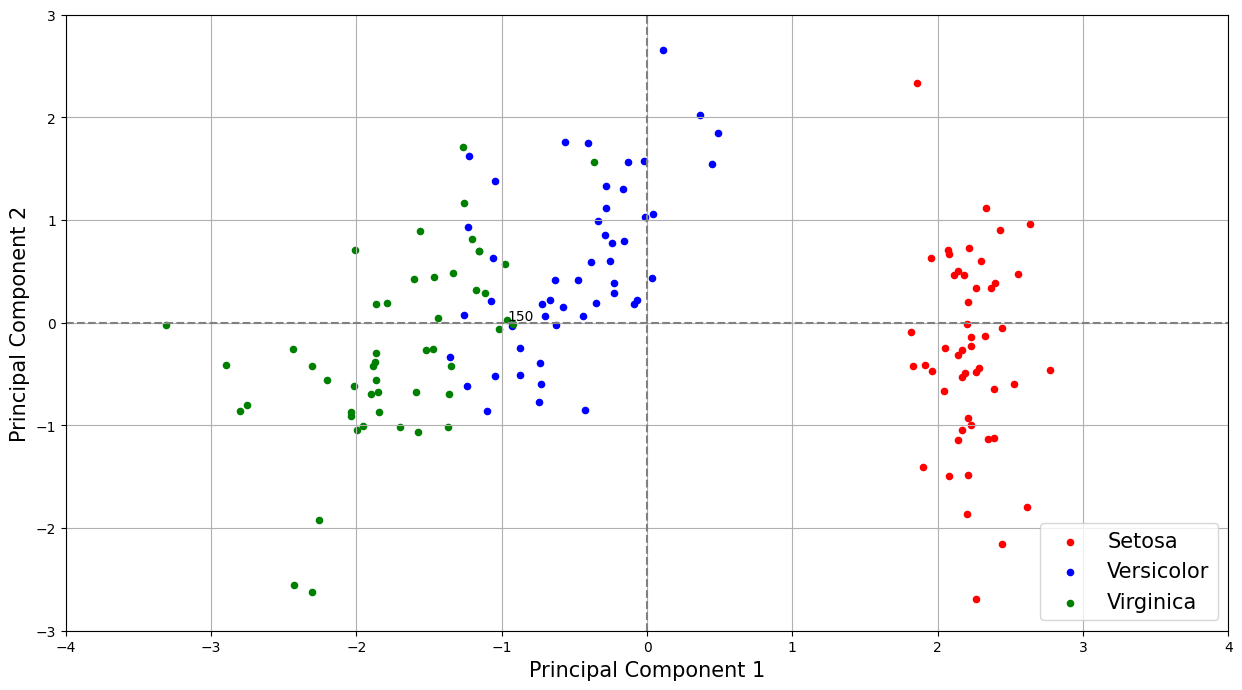

In [18]:
def plot_scatter(pc1, pc2):
    fig, ax = plt.subplots(figsize=(15, 8))
    species_unique = list(set(species))
    species_colors = ["r","b","g"]
    for i, spec in enumerate(species):
        plt.scatter(pc1[i], pc2[i], label = spec, s = 20,
c=species_colors[species_unique.index(spec)])
    ax.annotate(str(i+1), (pc1[i],pc2[i]))
    from collections import OrderedDict
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), prop={'size': 15}, loc=4)
    ax.set_xlabel('Principal Component 1', fontsize = 15)
    ax.set_ylabel('Principal Component 2', fontsize = 15)
    ax.axhline(y=0, color="grey", linestyle="--")
    ax.axvline(x=0, color="grey", linestyle="--")
    plt.grid()
    plt.axis([-4, 4, -3, 3])
    plt.show()
plot_scatter(pc1, pc2)

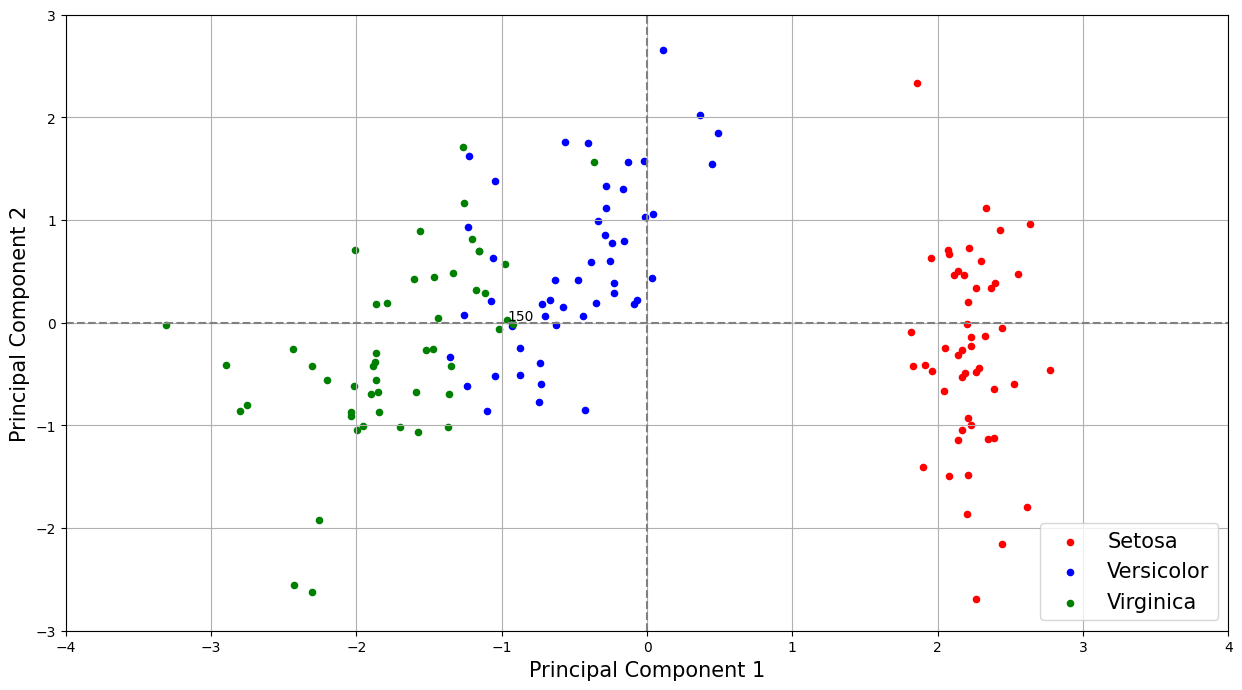

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Read csv data file, change to your location
df = pd.read_csv("C:\\Users\\PC\\OneDrive\\Desktop\\Học máy\\23000104_NguyenHuuDung_PCA\\iris.csv")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X = df.drop("variety", axis = 1)
X = StandardScaler().fit_transform(X)
pca = PCA()
result = pca.fit_transform(X)
# Remember what we said about the sign of eigen vectors that might change ?
pc1 = - result[:,0]
pc2 = - result[:,1]
plot_scatter(pc1, pc2)

In [22]:
U = eigens_vector[:,0:2]
U



array([[-0.52106591, -0.37741762],
       [ 0.26934744, -0.92329566],
       [-0.5804131 , -0.02449161],
       [-0.56485654, -0.06694199]])